# What Actually Makes a Premier League Player Worth More?

A plain-English tour through everything we found digging into Premier League transfer values: what really moves the price tag, which players might be worth a lot more a year from now, how well those predictions have actually held up, and whether playing for a "big club" inflates your value beyond what you've actually done on the pitch.

No stats jargon here — just the findings. (If you want the full technical breakdown, it's in the other notebooks in this project: 05 for how the predictions were tested and 06 for why they work and when they don't.)

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

from src.panel import build_snapshot_panel
from src.modeling import default_backtest_cutoffs, walk_forward_backtest
from src.forecast import load_forecasts

sns.set_theme(style="whitegrid", context="talk")
USD_PER_EUR = 1.08

panel = build_snapshot_panel()
panel["current_value_usd_m"] = panel["current_value_eur"] * USD_PER_EUR / 1_000_000
print(f"Loaded {panel.shape[0]:,} historical valuations for Premier League players.")

Loaded 33,748 historical valuations for Premier League players.


## 1. How much is a Premier League player actually worth?

Most players are worth far less than the headline transfer fees you hear about. A small number of superstars pull the average way up — most of the squad is nowhere near that.

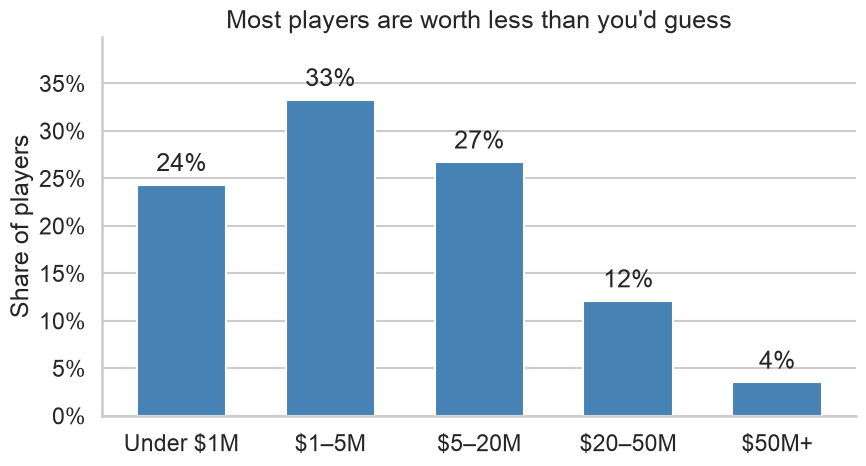

In [2]:
bins = [0, 1, 5, 20, 50, 1000]
labels = ["Under $1M", "$1–5M", "$5–20M", "$20–50M", "$50M+"]
bracket = pd.cut(panel["current_value_usd_m"], bins=bins, labels=labels)
share = (bracket.value_counts(normalize=True).reindex(labels) * 100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, share.values, color="steelblue", width=0.6)
ax.bar_label(bars, fmt="%.0f%%", padding=6)
ax.set_ylabel("Share of players")
ax.set_ylim(0, share.max() * 1.2)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0f}%")
ax.set_title("Most players are worth less than you'd guess")
sns.despine(ax=ax)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## 2. There's a sweet spot age

Value climbs through a player's early 20s, peaks in the mid-20s, then declines. It's not a straight line — young promise and late-career experience are both worth less than a player in their prime.

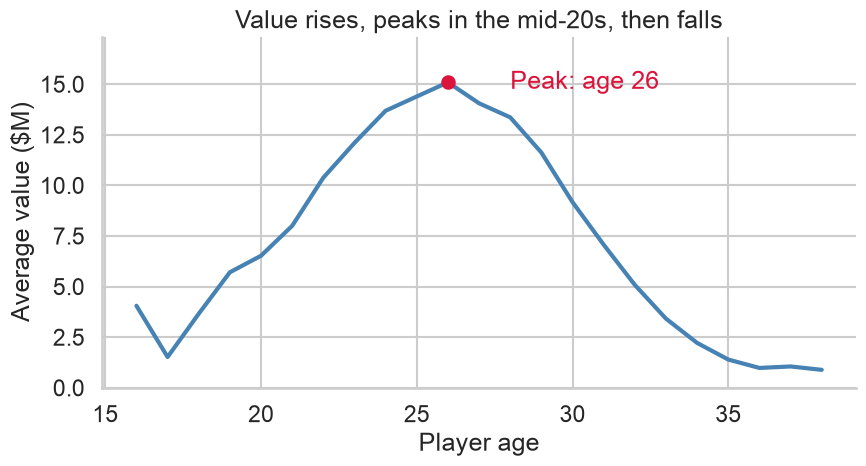

In [3]:
age_curve = panel.dropna(subset=["age"]).groupby(panel["age"].round())["current_value_usd_m"].mean()
age_curve = age_curve[(age_curve.index >= 16) & (age_curve.index <= 38)]
peak_age = int(age_curve.idxmax())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(age_curve.index, age_curve.values, color="steelblue", linewidth=3)
ax.scatter([peak_age], [age_curve.max()], color="crimson", zorder=5, s=80)
ax.annotate(
    f"Peak: age {peak_age}",
    xy=(peak_age, age_curve.max()),
    xytext=(peak_age + 2, age_curve.max()),
    color="crimson",
    va="center",
)
ax.set_xlabel("Player age")
ax.set_ylabel("Average value ($M)")
ax.set_ylim(0, age_curve.max() * 1.15)
ax.set_title("Value rises, peaks in the mid-20s, then falls")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 3. What actually moves the needle on value?

Scoring goals helps, obviously. But just being trusted with regular game time — playing every week, racking up minutes — matters at least as much as the goals themselves. A super-sub who scores in flashes is worth less than a guaranteed starter, even at similar output.

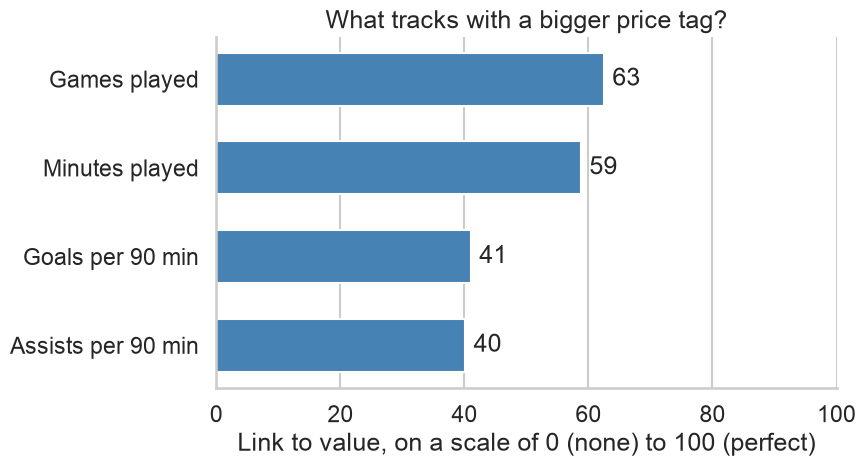

In [4]:
FRIENDLY_LABELS = {
    "trailing_goals_per90": "Goals per 90 min",
    "trailing_assists_per90": "Assists per 90 min",
    "trailing_minutes": "Minutes played",
    "trailing_appearances": "Games played",
}

log_value = np.log10(panel["current_value_eur"])
strength = (panel[list(FRIENDLY_LABELS)].corrwith(log_value).rename(FRIENDLY_LABELS) * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(strength.index, strength.values, color="steelblue", height=0.6)
ax.bar_label(bars, fmt="%.0f", padding=6)
ax.set_xlim(0, 100)
ax.set_xlabel("Link to value, on a scale of 0 (none) to 100 (perfect)")
ax.set_title("What tracks with a bigger price tag?")
sns.despine(ax=ax)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. Some positions just pay better

Flashy attacking positions carry a real premium — attacking midfielders and wingers are valued well above the league average, position for position, while goalkeepers and defensive-minded midfielders sit well below it.

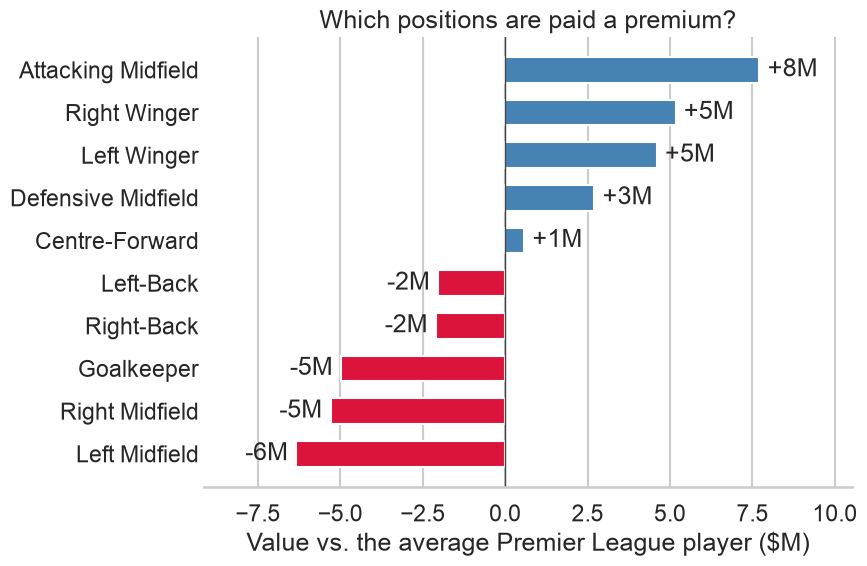

In [5]:
pos_stats = panel.groupby("sub_position")["current_value_usd_m"].agg(["mean", "count"])
pos_stats = pos_stats[pos_stats["count"] >= 15]
pos_stats["deviation"] = pos_stats["mean"] - panel["current_value_usd_m"].mean()
top_bottom = pd.concat([pos_stats.sort_values("deviation").head(5), pos_stats.sort_values("deviation").tail(5)]).sort_values("deviation")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["crimson" if v < 0 else "steelblue" for v in top_bottom["deviation"]]
bars = ax.barh(top_bottom.index, top_bottom["deviation"], color=colors, height=0.6)
ax.bar_label(bars, fmt="%+.0fM", padding=6)
ax.axvline(0, color="#444444", linewidth=1)
x_min, x_max = top_bottom["deviation"].min(), top_bottom["deviation"].max()
x_pad = (x_max - x_min) * 0.2
ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_xlabel("Value vs. the average Premier League player ($M)")
ax.set_title("Which positions are paid a premium?")
sns.despine(ax=ax, left=True)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

## 5. Ones to watch: predicted to jump in value

We trained a model on age, recent form, career history, each player's own valuation trend and their club's league position to project how much every player's value might change over the next 12 months. These are the exact predictions we froze to a file in this project (`forecasts/`), so they can be checked against reality later and can't be quietly revised. Here's who it flags as the biggest projected risers, in dollar terms, with the range the model itself puts around each one.

In [6]:
forecast = load_forecasts()
forecast = forecast[forecast["horizon_months"] == 12].copy()
as_of = forecast["snapshot_date"].max().date()
forecast["predicted_eur_change"] = forecast["predicted_value_eur"] - forecast["current_value_eur"]
forecast["Current value"] = (forecast["current_value_eur"] * USD_PER_EUR / 1_000_000).round(1).map("${}M".format)
forecast["Predicted in 12 months"] = (forecast["predicted_value_eur"] * USD_PER_EUR / 1_000_000).round(1).map("${}M".format)
forecast["Projected change"] = (forecast["predicted_pct_change"] * 100).round(0).astype(int).map("{:+d}%".format)
forecast["Likely range"] = forecast.apply(lambda r: f"{r['pct_q10'] * 100:+.0f}% to {r['pct_q90'] * 100:+.0f}%", axis=1)

top10 = forecast.sort_values("predicted_eur_change", ascending=False).head(10)
top10 = top10.rename(columns={"name": "Player", "sub_position": "Position"})
print(f"Predictions frozen as of {as_of}, for {len(forecast):,} players.")
top10[["Player", "Position", "Current value", "Predicted in 12 months", "Projected change", "Likely range"]].reset_index(drop=True)

Predictions frozen as of 2026-06-03, for 757 players.


,Player,Position,Current value,Predicted in 12 months,Projected change,Likely range
0,Rayan Cherki,Attacking Midfield,$97.2M,$115.5M,+19%,-17% to +50%
1,Elliot Anderson,Central Midfield,$81.0M,$98.3M,+21%,-19% to +48%
2,Max Dowman,Right Winger,$32.4M,$47.9M,+48%,-9% to +130%
3,Nico O'Reilly,Left-Back,$75.6M,$90.2M,+19%,-15% to +64%
4,Mateus Fernandes,Central Midfield,$54.0M,$66.1M,+22%,-17% to +71%
5,Ayden Heaven,Centre-Back,$32.4M,$43.0M,+33%,-13% to +117%
6,Abdukodir Khusanov,Centre-Back,$54.0M,$64.2M,+19%,-17% to +73%
7,Kobbie Mainoo,Central Midfield,$75.6M,$85.5M,+13%,-18% to +64%
8,William Osula,Centre-Forward,$30.2M,$39.6M,+31%,-21% to +87%
9,Rio Ngumoha,Left Winger,$32.4M,$40.5M,+25%,-9% to +120%


*Take this as a data-driven hunch, not a guarantee. The model only knows age, form, history and where the club sits in the table. It has no idea about injuries, transfer gossip, or contract standoffs. And notice how wide the "likely range" is: that's the model being honest about how uncertain a year in football is.*

## 6. Does it actually work?

Anyone can make a prediction. The question is whether it would have been right. So we tested it the way a scout would have used it: pretend it's a date in the past, train the model only on what was known then, predict a year ahead for every player, and check against what really happened. Then repeat, every six months, from 2017 to 2025.

The honest summary: it's a good **shortlist** and a bad **price tag**. If you sorted every player by our prediction and again by what actually happened, the two orders agree far more than chance, but far from perfectly. The useful part is the top of the list. Below, the players it flagged in its top 10% each time, against the average player.

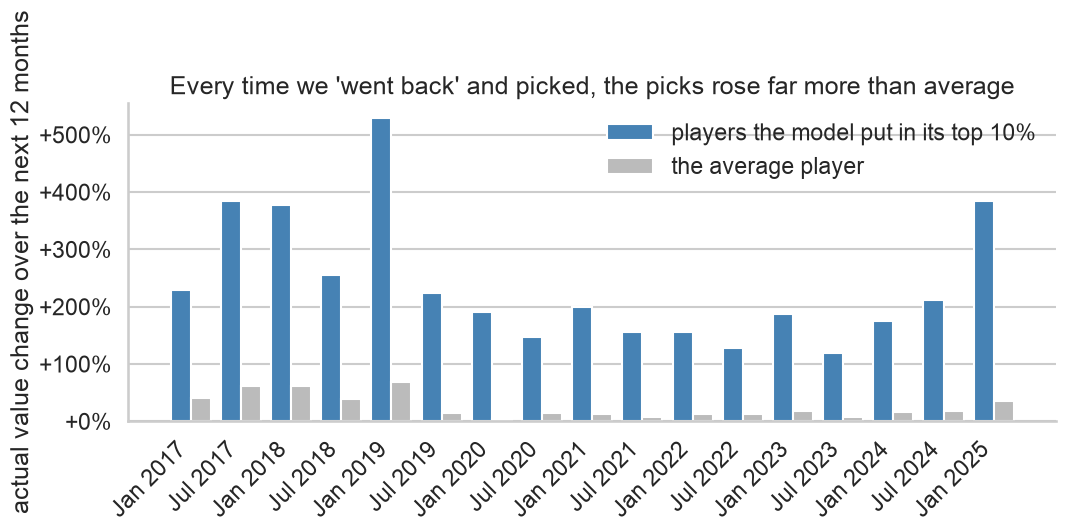

Across 17 test dates the model's top 10% rose +238% on average against +26% for everyone, and beat the average at 17 of 17 dates.


In [7]:
cutoffs = default_backtest_cutoffs(panel, months=12)
metrics, _ = walk_forward_backtest(panel, months=12, cutoffs=cutoffs, model_names=("xgboost",))
metrics = metrics.sort_values("cutoff")

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics))
width = 0.4
ax.bar(x - width / 2, metrics["mean_actual_top_decile"] * 100, width, color="steelblue", label="players the model put in its top 10%")
ax.bar(x + width / 2, metrics["mean_actual_all"] * 100, width, color="#bbbbbb", label="the average player")
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b %Y") for d in metrics["cutoff"]], rotation=45, ha="right")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_ylabel("actual value change over the next 12 months")
ax.set_title("Every time we 'went back' and picked, the picks rose far more than average")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

beat = (metrics["mean_actual_top_decile"] > metrics["mean_actual_all"]).sum()
print(f"Across {len(metrics)} test dates the model's top 10% rose {metrics['mean_actual_top_decile'].mean():+.0%} on average "
      f"against {metrics['mean_actual_all'].mean():+.0%} for everyone, and beat the average at {beat} of {len(metrics)} dates.")

Those averages are pulled up by a handful of teenagers whose value multiplied ten or twenty times over; the typical pick rose by much less. That's the point, though: the list finds the breakouts, it just can't tell you how big they'll be.

Three things it gets wrong, so you know when not to trust it:

- **Players who leave the league.** Someone moving from the Premier League to Spain or Italy usually gets marked down, and the model can't see the move coming.
- **Relegation.** A good player at a club that goes down loses value regardless. The model now watches the league table, which fixed nearly half of that blind spot, but it can't know in October how May will end.
- **The whole market moving.** In 2020 every valuation was cut. Nothing about an individual player could have predicted that, and the model has been a touch too optimistic ever since.

## 7. Does playing for a big club inflate your value?

Short answer: **yes, noticeably**. We built a model that predicts value purely from what a player has actually done on the pitch — age, output, minutes, position — with no knowledge of which club they play for. Comparing real values to that stats-only prediction shows a clear gap for the traditional "big six."

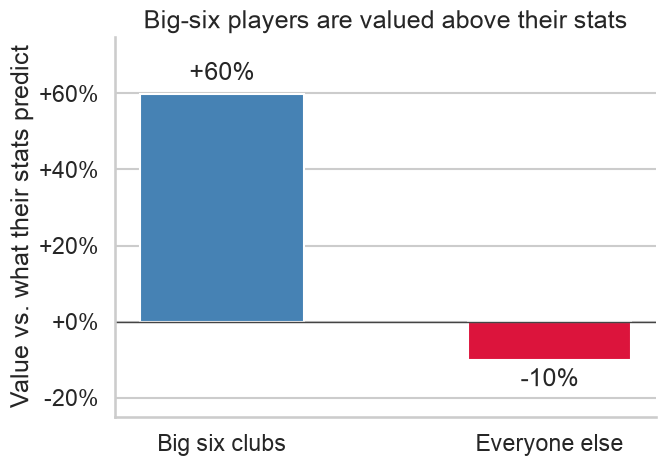

Big-six players are valued roughly 1.8x higher than their on-pitch stats alone would predict, compared to everyone else.


In [8]:
NUMERIC = ["age", "trailing_goals_per90", "trailing_assists_per90", "trailing_minutes", "trailing_appearances", "trailing_avg_club_position"]
CATEGORICAL = ["sub_position", "foot"]

model_df = panel.copy()
model_df["foot"] = model_df["foot"].fillna("unknown")
model_df["sub_position"] = model_df["sub_position"].fillna("unknown")
model_df["log_value"] = np.log10(model_df["current_value_eur"])
model_df = model_df.dropna(subset=NUMERIC + ["log_value"]).reset_index(drop=True)

preprocessor = ColumnTransformer([("num", StandardScaler(), NUMERIC), ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])
stats_only_model = Pipeline([("preprocess", preprocessor), ("model", XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42))])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
predicted_log_value = cross_val_predict(stats_only_model, model_df[NUMERIC + CATEGORICAL], model_df["log_value"], cv=kfold)
model_df["value_gap"] = model_df["log_value"] - predicted_log_value

BIG_SIX = ["Arsenal", "Chelsea", "Liverpool", "Manchester City", "Manchester United", "Tottenham Hotspur"]
model_df["group"] = np.where(model_df["current_club_name"].apply(lambda n: any(c in n for c in BIG_SIX)), "Big six clubs", "Everyone else")

# Average in log space first (the statistically correct way to summarize a log-ratio),
# then convert each group's average to a plain "% vs. what stats predict" for display.
# Averaging the per-player percentages directly instead would overstate both bars,
# since exponentiating before averaging skews upward on heavy-tailed data.
mean_log_gap = model_df.groupby("group")["value_gap"].mean().reindex(["Big six clubs", "Everyone else"])
group_pct = (10 ** mean_log_gap - 1) * 100

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["crimson" if v < 0 else "steelblue" for v in group_pct]
bars = ax.bar(group_pct.index, group_pct.values, color=colors, width=0.5)
ax.bar_label(bars, fmt="%+.0f%%", padding=6)
ax.axhline(0, color="#444444", linewidth=1)
y_min, y_max = min(0, group_pct.min()), group_pct.max()
ax.set_ylim(y_min - 15, y_max + 15)
ax.set_ylabel("Value vs. what their stats predict")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_title("Big-six players are valued above their stats")
sns.despine(ax=ax)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

premium_multiplier = (1 + group_pct["Big six clubs"] / 100) / (1 + group_pct["Everyone else"] / 100)
print(f"Big-six players are valued roughly {premium_multiplier:.1f}x higher than their on-pitch stats alone would predict, compared to everyone else.")

Interestingly, when we checked the same thing for a player's nationality (comparing players from football's biggest media markets — England, Brazil, France, Spain, Argentina, Germany — to everyone else), there was **no meaningful gap at all**. So the "reputation premium" here looks like a club-prestige story, not a where-are-you-from story.

## The bottom line

- Value peaks in the mid-20s, not at debut and not at 30+.
- Getting picked to play regularly matters as much as scoring goals.
- Attacking positions are paid a premium over defensive ones, even accounting for output.
- Tested as if we had used it every six months since 2017, the model's top picks rose several times more than the average player in every single window. It's a good shortlist and a bad price tag.
- It fails in predictable places: players who leave the league, clubs that go down, and years when the whole market moves.
- Big-six clubs come with a real value bump beyond what a player's stats justify — nationality doesn't.
- Every prediction here is pattern-matching on age, stats, history and the league table. None of it knows about injuries, dressing-room politics, or a director of football's gut feeling — treat it as a starting point for an argument, not the final word.